<a href="https://colab.research.google.com/github/P1nkman9/Traffic-Prediction-by-Using-LSTM-Forecasting-and-LLM/blob/main/Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Traffic Prediction by Using LSTM Forecasting and Large Language Model**

# **Introduction**

Traffic congestion is a common and irritating issue in modern transportation systems. Accurate predictions can support traffic management and help drivers and city planners improve route planning. This project aims to predict short-term traffic conditions using historical traffic sensor data from road networks. The model uses past speed patterns from multiple locations simultaneously to predict the traffic congestion level across those same spots later on.

# **Key Objects**
1.	To develop a machine learning model for predicting short-term traffic speeds using historical data.
2.	To investigate the effectiveness of LSTM networks in tracking and predicting traffic patterns over time.
3.	To evaluate the prediction performance over different future time interval (e.g. 15, 30, and 60 minutes ahead).
4.	To integrate a LLM for natural-language explanation and user interaction.

# **Data Overview**
This project uses Los Angeles traffic dataset from Github(https://github.com/hazdzz/dcrnn_data). It contains historical highway traffic speed measurements in year 2012. The data were collected from multiple fixed road sensors across the Los Angeles metropolitan area.

Each row in the dataset corresponds to a specific timestamp, and each column represents the average vehicle speed recorded at a particular sensor location. The data are organized chronologically and cover approximately 4 months of records.

To evaluate the models, the dataset is divided into training, validation, and test sets in chronological order with ratios of 0.7, 0.1, and 0.2, respectively. In addition, the average speed values are converted into the Speed Performance Index (SPI) to better reflect traffic congestion levels.


# **1. LSTM Implementation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports

In [ ]:
import numpy as np
import pandas as pd
import json
import os
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import time
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

# Reproducibility
SEED = 1
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Data Loading

In [ ]:
raw = pd.read_csv("/content/drive/MyDrive/ELEC0149/final/vel_metr_la.csv", header=None) # CHANGE TO YOUR OWN PATH

### Data Preprocessing

In [ ]:
# Extract sensor ID
sensor_ids = raw.iloc[0, 1:].to_numpy()

# Extract and clean timestamp data
times = pd.to_datetime(raw.iloc[1:, 0], errors="coerce")
valid_mask = times.notna()
times = times[valid_mask]

# Extract and clean speed feature data
speed_df = (
    raw.iloc[1:, 1:]
    .astype(float)
    .loc[valid_mask.values]
    .replace(0.0, np.nan)
    .ffill()
    .bfill()
)

# Convert to the final model input format
V = speed_df.to_numpy(dtype=np.float32)  # (T, S)
T, S = V.shape
print("Data shape:", V.shape)

Data shape: (34272, 207)


### Train / Validation / Test Split

Chronological split with ratios 0.7 / 0.1 / 0.2 to preserve temporal ordering.

In [ ]:
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1

train_end = int(T * TRAIN_RATIO)
val_end = int(T * (TRAIN_RATIO + VAL_RATIO))

V_train = V[:train_end]
V_val = V[train_end:val_end]
V_test = V[val_end:]

print(f"Train / Val / Test: {len(V_train)} / {len(V_val)} / {len(V_test)} time steps")

Train / Val / Test: 23990 / 3427 / 6855 time steps


### Free-Flow Speed

The 85th-percentile speed of each sensor computed on the training set is used as the per-sensor free-flow reference speed.

In [ ]:
FREEFLOW_Q = 0.85
vfree = np.quantile(V_train, FREEFLOW_Q, axis=0)
vfree = np.maximum(vfree, 1e-6)

### SPI Calculation
SPI can better reflect the congestion level than average speed:

$$
SPI = \frac{V_{current}}{V_{free}}
$$

In this project, 3 congestion classes will be considered and trained for prediction:

Free: SPI > 0.75

Moderate Congestion: 0.5 < SPI <= 0.75

Severe Congestion: SPI <= 0.5

In [ ]:
SPI_THRESH_FREE = 0.75
SPI_THRESH_MOD = 0.5

SPI = np.clip(V / vfree, 0.0, 1.0)

#### SPI Standardisation

`StandardScaler` is fitted on the training split only to prevent data leakage.

In [ ]:
scaler = StandardScaler()
scaler.fit(SPI[:train_end])
SPI_scaled = scaler.transform(SPI)

#### Generate LSTM Training Samples

In [ ]:
# Define time window parameters
LOOKBACK = 24   # 24 steps = 120 minutes of context
HORIZON = 12   # 12 steps = 60 minutes ahead

def make_windows(X2d: np.ndarray, lookback: int, horizon: int):
    """Return sliding-window samples (X, y) from a 2-D time series."""
    xs, ys = [], []
    max_i = len(X2d) - horizon
    for i in range(lookback, max_i + 1):
        xs.append(X2d[i - lookback:i])
        ys.append(X2d[i + horizon - 1])
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

# Generate all sliding window data
X_all, y_all = make_windows(SPI_scaled, LOOKBACK, HORIZON)

def idx_to_window_row(label_time_idx: int, lookback: int, horizon: int) -> int:
    return label_time_idx - (lookback + horizon - 1)

# Calculate partition nodes
train_row_end = idx_to_window_row(train_end - 1, LOOKBACK, HORIZON) + 1
val_row_end = idx_to_window_row(val_end - 1, LOOKBACK, HORIZON) + 1

# Temporal segmentation training set, validation set, and test set
train_X, train_y = X_all[:train_row_end], y_all[:train_row_end]
val_X, val_y = X_all[train_row_end:val_row_end], y_all[train_row_end:val_row_end]
test_X, test_y = X_all[val_row_end:], y_all[val_row_end:]

print(f"Lookback {LOOKBACK} steps ({LOOKBACK*5} min) → Horizon {HORIZON} steps ({HORIZON*5} min)")
print(f"Train / Val / Test windows: {train_X.shape[0]} / {val_X.shape[0]} / {test_X.shape[0]}")

Lookback 24 steps (120 min) → Horizon 12 steps (60 min)
Train / Val / Test windows: 23955 / 3427 / 6855


## Baseline Model (Persistence) — H = 12 (60 minutes ahead)

A **Persistence (Naive Forecast)** model predicts the future by repeating the last observed value: ŷ(t+h) = x(t). The primary prediction task in this notebook is **H = 12 steps = 60 minutes ahead**.

At short horizons (5 min), persistence is very hard to beat because traffic speed barely changes in 5 minutes. At 60 minutes ahead, traffic conditions can change substantially — this is where the LSTM learns meaningful temporal patterns that persistence cannot capture.


In [ ]:
def spi_to_class(spi: np.ndarray) -> np.ndarray:
    """
    Convert SPI values into 3 congestion classes:
        0 = Normal traffic (SPI > SPI_THRESH_FREE)
        1 = Moderate congestion (SPI_THRESH_MOD < SPI <= SPI_THRESH_FREE)
        2 = Severe congestion (SPI <= SPI_THRESH_MOD)
    """
    cls = np.zeros_like(spi, dtype=np.int32)
    cls[(spi <= SPI_THRESH_FREE) & (spi > SPI_THRESH_MOD)] = 1
    cls[(spi <= SPI_THRESH_MOD)] = 2
    return cls


def baseline_persistence(X_test: np.ndarray, scaler) -> np.ndarray:
    """
    Naive persistence baseline: predict the last observed SPI value in the window.
    The last SPI value observed within the current time window is used directly as the prediction value for the future.
    """
    pred_scaled = X_test[:, -1, :]  # Feature data from all samples, the last time step, and all sensors.
    pred_spi = scaler.inverse_transform(pred_scaled)
    return np.clip(pred_spi, 0.0, 1.0)


# Evaluate baseline on test set
# Obtain the predicted values from the baseline model.
base_pred_spi = baseline_persistence(test_X, scaler)
# To obtain the actual label values, inverse normalization and truncation to [0.0, 1.0] are also required.
base_true_spi = np.clip(scaler.inverse_transform(test_y), 0.0, 1.0)

# Calculate regression evaluation indicators
base_mae = np.mean(np.abs(base_pred_spi - base_true_spi))
base_rmse = np.sqrt(np.mean((base_pred_spi - base_true_spi) ** 2))

# Convert to a classification task and calculate classification evaluation metrics.
base_pred_cls = spi_to_class(base_pred_spi).reshape(-1)
base_true_cls = spi_to_class(base_true_spi).reshape(-1)
base_acc = accuracy_score(base_true_cls, base_pred_cls)
base_mf1 = f1_score(base_true_cls, base_pred_cls, average="macro")

print("=== Persistence Baseline Results ===")
print(f"MAE = {base_mae:.4f}")
print(f"RMSE = {base_rmse:.4f}")
print(f"Accuracy = {base_acc:.4f}")
print(f"Macro-F1 = {base_mf1:.4f}")


=== Persistence Baseline Results ===
MAE = 0.0719
RMSE = 0.1483
Accuracy = 0.8849
Macro-F1 = 0.6480


## LSTM Model

**LSTMForecaster** — single-layer LSTM with `LayerNorm` and `Dropout(0.3)`, trained with `L1Loss` and `Adam` (lr=5e-4, weight_decay=1e-4). Early stopping with patience=10 and min_delta=1e-4 guards against over-training.

In [ ]:
# Model definition
class LSTMForecaster(nn.Module):
    """Single-layer LSTM with LayerNorm and Dropout, followed by a linear output layer."""
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(self.norm(out[:, -1, :])))

# Data loader construction
def build_dataloaders(X_tr, y_tr, X_va, y_va, batch_size):
    tr_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    va_ds = TensorDataset(torch.from_numpy(X_va), torch.from_numpy(y_va))
    # The training set needs to be shuffled (shuffle=True) to improve generalization ability;
    # the validation set does not need to be shuffled.
    return (DataLoader(tr_ds, batch_size=batch_size, shuffle=True),
            DataLoader(va_ds, batch_size=batch_size, shuffle=False))

# Single-epoch training and validation functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    return total_loss / total_n

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)
    return total_loss / total_n

# Main training loop
def train_model(model, tr_loader, va_loader, epochs, optimizer, criterion,
                scheduler, device, patience=5, min_delta=1e-4,
                save_path='best_model.pt'):
    """
    Training loop with early stopping and best-weight restoration.
    min_delta: minimum improvement required to reset the patience counter.
    patience: number of epochs without meaningful improvement before stopping.
    """
    best_val_loss = float('inf')
    patience_counter = 0
    loss_arr, val_loss_arr = [], []

    start_time = time.time()
    for epoch in range(epochs):
        tr_loss = train_epoch(model, tr_loader, optimizer, criterion, device)
        va_loss = eval_epoch(model, va_loader, criterion, device)
        scheduler.step(va_loss)

        loss_arr.append(tr_loss)
        val_loss_arr.append(va_loss)

        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"Epoch {epoch+1:>2}/{epochs} | Train: {tr_loss:.5f}  Val: {va_loss:.5f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}  "
                  f"(best val: {best_val_loss:.5f})")
            break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    print(f"Training time: {time.time() - start_time:.2f} s")
    return loss_arr, val_loss_arr

# Model testing and evaluation
def evaluate_model(model, X_test, y_test, scaler, device):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.from_numpy(X_test).to(device)).cpu().numpy()

    pred_spi = np.clip(scaler.inverse_transform(pred_scaled), 0.0, 1.0)
    true_spi = np.clip(scaler.inverse_transform(y_test), 0.0, 1.0)

    mae = np.mean(np.abs(pred_spi - true_spi))
    rmse = np.sqrt(np.mean((pred_spi - true_spi) ** 2))

    pred_cls = spi_to_class(pred_spi).reshape(-1)
    true_cls = spi_to_class(true_spi).reshape(-1)
    acc = accuracy_score(true_cls, pred_cls)
    mf1 = f1_score(true_cls, pred_cls, average="macro")

    print(f"Test MAE = {mae:.4f} | RMSE = {rmse:.4f}")
    print(f"Test Accuracy = {acc:.4f} | Macro-F1 = {mf1:.4f}")
    return pred_spi, true_spi, pred_cls, true_cls, mae, rmse, acc, mf1

# Hyperparameter settings
EPOCHS = 60
BATCH_SIZE = 64
PATIENCE = 10
MIN_DELTA = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = train_X.shape[-1]
output_size = train_y.shape[-1]

model_lstm = LSTMForecaster(
    input_size = input_size,
    hidden_size = 128,
    output_size = output_size,
    dropout = 0.3
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(
    model_lstm.parameters(),
    lr = 5e-4,
    weight_decay = 1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5, min_lr=1e-5)

tr_loader, va_loader = build_dataloaders(train_X, train_y, val_X, val_y, BATCH_SIZE)

loss_arr, val_loss_arr = train_model(
    model_lstm, tr_loader, va_loader,
    epochs = EPOCHS,
    optimizer = optimizer,
    criterion = criterion,
    scheduler = scheduler,
    device = device,
    patience = PATIENCE,
    min_delta = MIN_DELTA,
    save_path = 'best_model.pt'
)


Epoch  1/60 | Train: 0.51012  Val: 0.40431
Epoch  2/60 | Train: 0.40138  Val: 0.38798
Epoch  3/60 | Train: 0.38335  Val: 0.38226
Epoch  4/60 | Train: 0.37537  Val: 0.37968
Epoch  5/60 | Train: 0.37045  Val: 0.37952
Epoch  6/60 | Train: 0.36631  Val: 0.38022
Epoch  7/60 | Train: 0.36393  Val: 0.37806
Epoch  8/60 | Train: 0.36121  Val: 0.37804
Epoch  9/60 | Train: 0.35953  Val: 0.37679
Epoch 10/60 | Train: 0.35754  Val: 0.38051
Epoch 11/60 | Train: 0.35649  Val: 0.37793
Epoch 12/60 | Train: 0.35502  Val: 0.37767
Epoch 13/60 | Train: 0.35387  Val: 0.38005
Epoch 14/60 | Train: 0.35044  Val: 0.38081
Epoch 15/60 | Train: 0.34953  Val: 0.38268
Epoch 16/60 | Train: 0.34881  Val: 0.37915
Epoch 17/60 | Train: 0.34807  Val: 0.38163
Epoch 18/60 | Train: 0.34642  Val: 0.38105
Epoch 19/60 | Train: 0.34577  Val: 0.38079
Early stopping at epoch 19  (best val: 0.37679)
Training time: 28.89 s


## Model Evaluation

In [ ]:
pred_spi, true_spi, pred_cls, true_cls, lstm_mae, lstm_rmse, lstm_acc, lstm_mf1 = evaluate_model(
    model_lstm, test_X, test_y, scaler, device
)

Test MAE = 0.0615 | RMSE = 0.1221
Test Accuracy = 0.8949 | Macro-F1 = 0.6452


## Results Comparison — H = 12 (60 minutes ahead)

In [ ]:
# The evaluation metrics of the two models are summarized into a single list called rows.
rows = [
    ("Baseline", base_mae, base_rmse, base_acc, base_mf1),
    ("LSTM", lstm_mae, lstm_rmse, lstm_acc, lstm_mf1),
]

header = f"{'Model':<28} {'MAE':>7} {'RMSE':>7} {'Accuracy':>10} {'Macro-F1':>10}"
sep = "-" * len(header)

print("=== H=12 (60 min ahead) — Test Set Results ===")
print(header)
print(sep)
for name, mae, rmse, acc, mf1 in rows:
    print(f"{name:<28} {mae:>7.4f} {rmse:>7.4f} {acc:>10.4f} {mf1:>10.4f}")

print()
for metric, base_val, lstm_val, higher_better in [
    ("MAE", base_mae, lstm_mae, False),
    ("RMSE", base_rmse, lstm_rmse, False),
    ("Accuracy", base_acc, lstm_acc, True),
    ("Macro-F1", base_mf1, lstm_mf1, True),
]:
    if not higher_better:
        pct = (base_val - lstm_val) / base_val * 100
        sign = "improvement" if pct > 0 else "regression"
    else:
        pct = (lstm_val - base_val) / base_val * 100
        sign = "improvement" if pct > 0 else "regression"
    print(f"{metric:<10}: LSTM vs Persistence {pct:+.1f}% [{sign}]")


=== H=12 (60 min ahead) — Test Set Results ===
Model                            MAE    RMSE   Accuracy   Macro-F1
------------------------------------------------------------------
Baseline                      0.0719  0.1483     0.8849     0.6480
LSTM                          0.0615  0.1221     0.8949     0.6452

MAE       : LSTM vs Persistence +14.5% [improvement]
RMSE      : LSTM vs Persistence +17.7% [improvement]
Accuracy  : LSTM vs Persistence +1.1% [improvement]
Macro-F1  : LSTM vs Persistence -0.4% [regression]


## Multi-Horizon Comparison

A dedicated `LSTMForecaster` is trained for each horizon H ∈ {1, 3, 6, 12} steps (5, 15, 30, 60 minutes ahead) to show how prediction difficulty grows with horizon and where LSTM gains an advantage over Persistence.

In [ ]:
# Define the future time span to be tested
HORIZONS_TO_TEST = [1, 3, 6, 12]   # steps → 5, 15, 30, 60 minutes ahead
horizon_results = []

for H in HORIZONS_TO_TEST:
    print(f"\nHorizon H={H}  ({H * 5} minutes ahead)")

    # Dynamically adjust the size of the history window
    dynamic_lookback = max(6, 2 * H)

    # Regenerate sliding window sample pairs that adapt to the current Lookback and Horizon.
    X_h, y_h = make_windows(SPI_scaled, dynamic_lookback, H)

    # Re-splitting the training, validation, and test sets
    tr_end_h = idx_to_window_row(train_end - 1, dynamic_lookback, H) + 1
    va_end_h = idx_to_window_row(val_end - 1, dynamic_lookback, H) + 1

    tr_X_h, tr_y_h = X_h[:tr_end_h], y_h[:tr_end_h]
    va_X_h, va_y_h = X_h[tr_end_h:va_end_h], y_h[tr_end_h:va_end_h]
    te_X_h, te_y_h = X_h[va_end_h:], y_h[va_end_h:]

    # Evaluate the baseline model for the current period
    b_pred = baseline_persistence(te_X_h, scaler)
    b_true = np.clip(scaler.inverse_transform(te_y_h), 0.0, 1.0)

    b_mae = float(np.mean(np.abs(b_pred - b_true)))
    b_rmse = float(np.sqrt(np.mean((b_pred - b_true) ** 2)))
    b_acc = float(accuracy_score(spi_to_class(b_true).reshape(-1), spi_to_class(b_pred).reshape(-1)))
    b_mf1 = float(f1_score(spi_to_class(b_true).reshape(-1), spi_to_class(b_pred).reshape(-1), average="macro"))

    # Build and train a brand new LSTM model
    m_h = LSTMForecaster(input_size=input_size, hidden_size=128, output_size=output_size, dropout=0.3).to(device)
    opt_h = torch.optim.Adam(m_h.parameters(), lr=5e-4, weight_decay=1e-4)
    sch_h = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_h, patience=3, factor=0.5, min_lr=1e-5)

    tr_l_h, va_l_h = build_dataloaders(tr_X_h, tr_y_h, va_X_h, va_y_h, BATCH_SIZE)

    train_model(m_h, tr_l_h, va_l_h,
                epochs=EPOCHS, optimizer=opt_h, criterion=criterion,
                scheduler=sch_h, device=device, patience=PATIENCE,
                min_delta=MIN_DELTA,
                save_path=f'best_model_h{H}.pt')

    # Evaluate the LSTM model trained in the current cycle on the test set.
    _, _, _, _, l_mae, l_rmse, l_acc, l_mf1 = evaluate_model(m_h, te_X_h, te_y_h, scaler, device)

    # Aligned result comparison for this horizon
    row_hdr = f"  {'Model':<12} {'MAE':>8} {'RMSE':>8} {'Accuracy':>10} {'Macro-F1':>10}"
    row_sep = "  " + "-" * (len(row_hdr) - 2)
    print(row_sep)
    print(row_hdr)
    print(row_sep)
    print(f"  {'Baseline':<12} {b_mae:>8.4f} {b_rmse:>8.4f} {b_acc:>10.4f} {b_mf1:>10.4f}")
    print(f"  {'LSTM':<12} {l_mae:>8.4f} {l_rmse:>8.4f} {l_acc:>10.4f} {l_mf1:>10.4f}")

    # Save the results of the current period to a dictionary.
    horizon_results.append({
        "H": H, "minutes": H * 5,
        "base_mae": b_mae, "base_rmse": b_rmse,
        "base_acc": b_acc, "base_mf1": b_mf1,
        "lstm_mae": l_mae, "lstm_rmse": l_rmse,
        "lstm_acc": l_acc, "lstm_mf1": l_mf1,
    })

print("\n\n=== Multi-Horizon Summary ===")
hdr = f"  {'Model':<12} {'H':>3} {'Min':>5} {'MAE':>8} {'RMSE':>8} {'Accuracy':>10} {'Macro-F1':>10}"
sep = "  " + "-" * (len(hdr) - 2)
print(hdr)
print(sep)
for r in horizon_results:
    print(f"  {'Baseline':<12} {r['H']:>3} {r['minutes']:>5}"
          f" {r['base_mae']:>8.4f} {r['base_rmse']:>8.4f}"
          f" {r['base_acc']:>10.4f} {r['base_mf1']:>10.4f}")
    print(f"  {'LSTM':<12} {r['H']:>3} {r['minutes']:>5}"
          f" {r['lstm_mae']:>8.4f} {r['lstm_rmse']:>8.4f}"
          f" {r['lstm_acc']:>10.4f} {r['lstm_mf1']:>10.4f}")
    print(sep)



Horizon H=1  (5 minutes ahead)
Epoch  1/60 | Train: 0.48005  Val: 0.36587
Epoch  2/60 | Train: 0.36737  Val: 0.34319
Epoch  3/60 | Train: 0.35123  Val: 0.33432
Epoch  4/60 | Train: 0.34377  Val: 0.32628
Epoch  5/60 | Train: 0.33970  Val: 0.32281
Epoch  6/60 | Train: 0.33636  Val: 0.31885
Epoch  7/60 | Train: 0.33368  Val: 0.31734
Epoch  8/60 | Train: 0.33127  Val: 0.31500
Epoch  9/60 | Train: 0.32940  Val: 0.31306
Epoch 10/60 | Train: 0.32723  Val: 0.31245
Epoch 11/60 | Train: 0.32541  Val: 0.31077
Epoch 12/60 | Train: 0.32431  Val: 0.30842
Epoch 13/60 | Train: 0.32270  Val: 0.30810
Epoch 14/60 | Train: 0.32122  Val: 0.30707
Epoch 15/60 | Train: 0.31949  Val: 0.30467
Epoch 16/60 | Train: 0.31875  Val: 0.30423
Epoch 17/60 | Train: 0.31766  Val: 0.30354
Epoch 18/60 | Train: 0.31649  Val: 0.30282
Epoch 19/60 | Train: 0.31582  Val: 0.30148
Epoch 20/60 | Train: 0.31510  Val: 0.30143
Epoch 21/60 | Train: 0.31408  Val: 0.30177
Epoch 22/60 | Train: 0.31392  Val: 0.30066
Epoch 23/60 | Train: 0

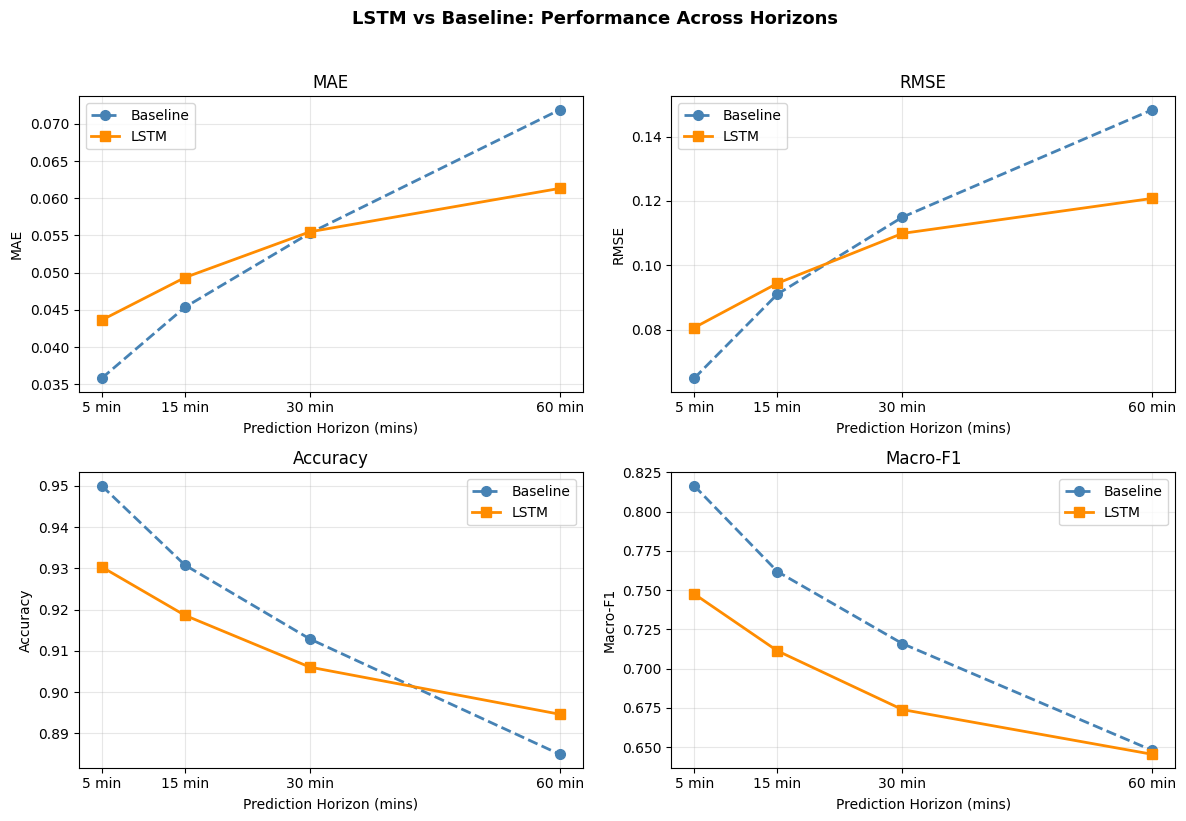

In [ ]:
# Comparison of 4 metrics (MAE, RMSE, Accuracy, Macro-F1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

metrics = [
    ("MAE", "base_mae", "lstm_mae"),
    ("RMSE", "base_rmse", "lstm_rmse"),
    ("Accuracy", "base_acc", "lstm_acc"),
    ("Macro-F1", "base_mf1", "lstm_mf1"),
]

x_vals = [r["minutes"] for r in horizon_results]
x_ticks = [f"{m} min" for m in x_vals]

for ax, (title, bk, lk) in zip(axes, metrics):
    y_base = [r[bk] for r in horizon_results]
    y_lstm = [r[lk] for r in horizon_results]

    ax.plot(x_vals, y_base, "o--", color="steelblue", label="Baseline", linewidth=2, markersize=7)
    ax.plot(x_vals, y_lstm, "s-", color="darkorange", label="LSTM", linewidth=2, markersize=7)

    ax.set_xlabel("Prediction Horizon (mins)")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_ticks)

plt.suptitle("LSTM vs Baseline: Performance Across Horizons", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Data Visualisation

# Loss Curve

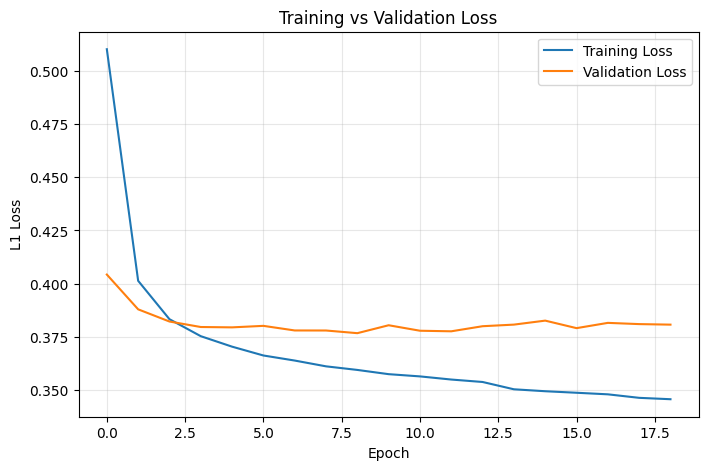

In [ ]:
# Plot the loss curve during model training.
def plot_loss_curves(loss_arr, val_loss_arr):
    plt.figure(figsize=(8, 5))
    plt.plot(loss_arr, label="Training Loss")
    plt.plot(val_loss_arr, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("L1 Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss_curves(loss_arr, val_loss_arr)


# True SPI vs Predicted SPI

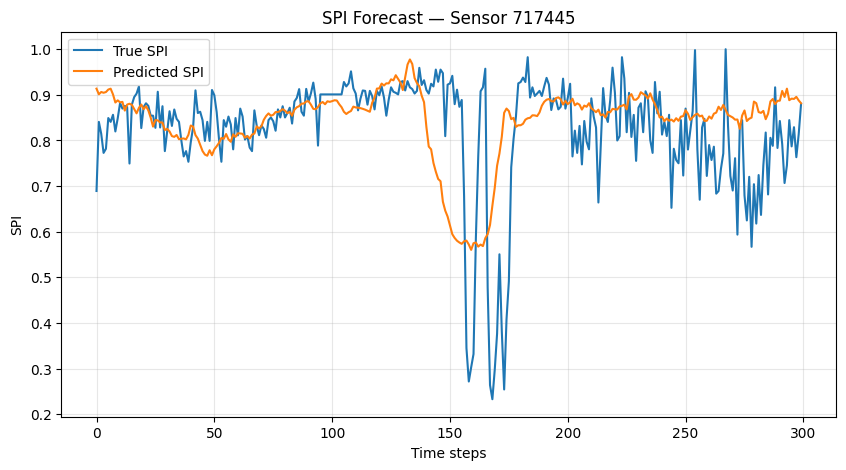

In [ ]:
# Plot a timing comparison diagram of the actual SPI and predicted SPI for a single sensor.
def plot_spi_timeseries(true_spi, pred_spi, sensor_ids, sensor_index=0, n_points=300):
    true_spi = np.asarray(true_spi)
    pred_spi = np.asarray(pred_spi)

    n_points = min(n_points, true_spi.shape[0])

    plt.figure(figsize=(10, 5))
    plt.plot(true_spi[:n_points, sensor_index], label="True SPI")
    plt.plot(pred_spi[:n_points, sensor_index], label="Predicted SPI")
    plt.xlabel("Time steps")
    plt.ylabel("SPI")
    plt.title(f"SPI Forecast — Sensor {int(float(sensor_ids[sensor_index]))}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Randomly selected sensor_index=5 for demonstration
plot_spi_timeseries(true_spi, pred_spi, sensor_ids, sensor_index=5, n_points=300)


# Scatter Plot: Predicted SPI vs True SPI

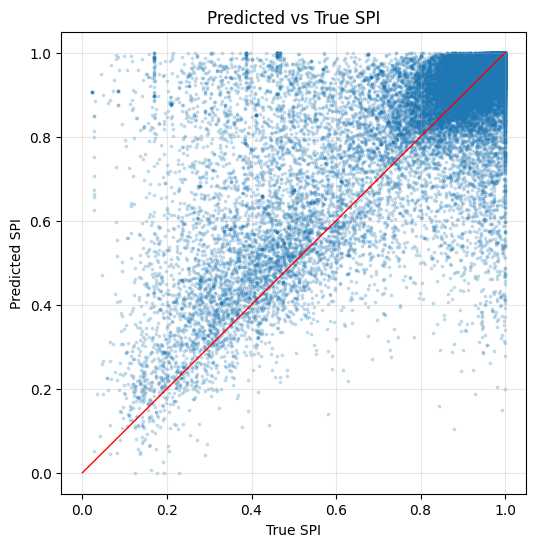

In [ ]:
# Plot a scatter plot of the actual SPI and the predicted SPI to assess the overall bias of the model's regression predictions.
def plot_spi_scatter(true_spi, pred_spi, sample_size=50000):
    true_flat = np.asarray(true_spi).reshape(-1)
    pred_flat = np.asarray(pred_spi).reshape(-1)

    n = len(true_flat)
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        true_flat = true_flat[idx]
        pred_flat = pred_flat[idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(true_flat, pred_flat, s=3, alpha=0.2)
    plt.xlabel("True SPI")
    plt.ylabel("Predicted SPI")
    plt.title("Predicted vs True SPI")
    plt.grid(True, alpha=0.3)

    mn = min(true_flat.min(), pred_flat.min())
    mx = max(true_flat.max(), pred_flat.max())
    plt.plot([mn, mx], [mn, mx], color="red", linewidth=1)
    plt.show()

plot_spi_scatter(true_spi, pred_spi)


# Confusion Matrix (3-Class Congestion)

<Figure size 600x500 with 0 Axes>

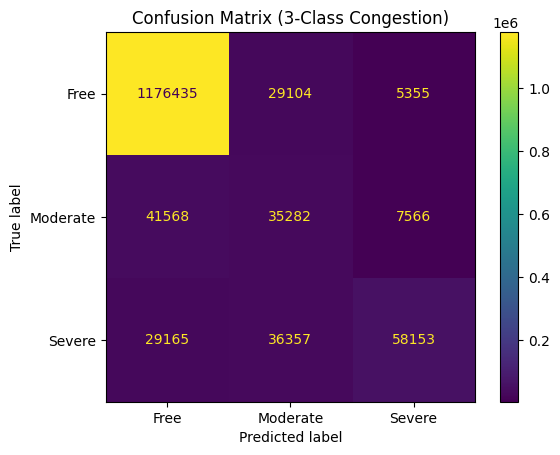

              precision    recall  f1-score   support

        Free       0.94      0.97      0.96   1210894
    Moderate       0.35      0.42      0.38     84416
      Severe       0.82      0.47      0.60    123675

    accuracy                           0.89   1418985
   macro avg       0.70      0.62      0.65   1418985
weighted avg       0.90      0.89      0.89   1418985



In [ ]:
# Plot and print the confusion matrix and classification assessment report.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

def plot_confusion_matrix_3class(true_cls, pred_cls):
    true_cls = np.asarray(true_cls).reshape(-1)
    pred_cls = np.asarray(pred_cls).reshape(-1)

    cm = confusion_matrix(true_cls, pred_cls, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Free", "Moderate", "Severe"])

    plt.figure(figsize=(6, 5))
    disp.plot(values_format="d")
    plt.title("Confusion Matrix (3-Class Congestion)")
    plt.grid(False)
    plt.show()

    print(classification_report(true_cls, pred_cls, target_names=["Free", "Moderate", "Severe"]))

plot_confusion_matrix_3class(true_cls, pred_cls)


# Class Distribution

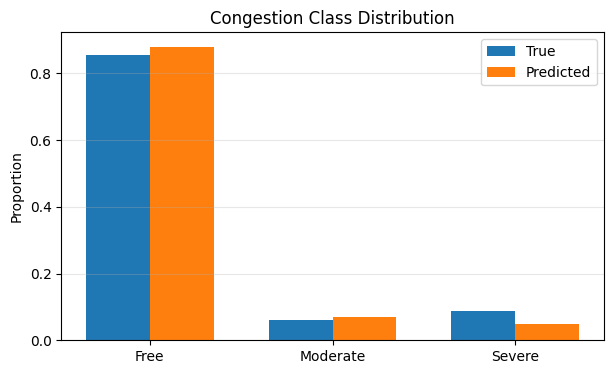

In [ ]:
# Plot side-by-side bar charts to compare the distribution of actual and predicted data across the three congestion categories.
def plot_class_distribution(true_cls, pred_cls):
    true_cls = np.asarray(true_cls).reshape(-1)
    pred_cls = np.asarray(pred_cls).reshape(-1)

    def pct(x):
        counts = np.bincount(x, minlength=3)
        return counts / counts.sum()

    p_true = pct(true_cls)
    p_pred = pct(pred_cls)

    labels = ["Free", "Moderate", "Severe"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width/2, p_true, width, label="True")
    plt.bar(x + width/2, p_pred, width, label="Predicted")
    plt.xticks(x, labels)
    plt.ylabel("Proportion")
    plt.title("Congestion Class Distribution")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

plot_class_distribution(true_cls, pred_cls)


# **2. LLM Model Implementation**

In [ ]:
!pip install -U google-genai
from google import genai

### SPI Classification for LLM Input

In [ ]:
# Convert continuous SPI into discrete congestion level categories.
def spi_to_class(spi, thresh_free=0.75, thresh_mod=0.5):
    """
    0: Free-flow
    1: Moderate congestion
    2: Severe congestion
    """
    spi = np.asarray(spi)
    cls = np.zeros_like(spi, dtype=np.int32)
    cls[(spi <= thresh_free) & (spi > thresh_mod)] = 1
    cls[(spi <= thresh_mod)] = 2
    return cls

### Forecast Summary Builder

In [ ]:
def summarize_forecast(pred_spi_future, sensor_ids, minutes_per_step=5, top_k=10):
    """
    Build a structured forecast summary for LLM consumption.
    pred_spi_future: shape (S,) or (H, S)
    sensor_ids:      shape (S,)
    """
    # Forced to NumPy array and manipulated dimensions
    pred = np.asarray(pred_spi_future)
    if pred.ndim == 1:
        pred = pred[None, :]  # -> (1, S)

    H, S = pred.shape
    cls = spi_to_class(pred)

    # Calculate global statistics step by step
    step_stats = []
    for h in range(H):
        counts = np.bincount(cls[h], minlength=3)
        step_stats.append({
            "step": int(h + 1),
            "minutes_ahead": int((h + 1) * minutes_per_step),
            "pct_free": int(round(counts[0] / S * 100)),
            "pct_moderate": int(round(counts[1] / S * 100)),
            "pct_severe": int(round(counts[2] / S * 100)),
            "mean_spi": round(float(np.mean(pred[h])), 3),
        })

    # Filter the most congested sensors across the entire network
    worst_spi = pred.min(axis=0)
    worst_idx = np.argsort(worst_spi)[:top_k]

    worst_list = [
        {"sensor_id": int(float(sensor_ids[i])),
         "min_spi": round(float(worst_spi[i]), 3)}
        for i in worst_idx
    ]

    # Screening sensors that exacerbate congestion the fastest
    if H >= 2:
        delta = pred[-1] - pred[0]
        worsen_idx = np.argsort(delta)[:top_k]

        worsen_list = [
            {"sensor_id": int(float(sensor_ids[i])),
             "spi_change": round(float(delta[i]), 3),
             "spi_start": round(float(pred[0, i]), 3),
             "spi_end": round(float(pred[-1, i]), 3)}
            for i in worsen_idx
        ]
    else:
        worsen_list = []

    # All analysis results are packaged into a dictionary, which is then sent as the Prompt Context to the large language model.
    return {
        "horizon_steps": int(H),
        "minutes_per_step": int(minutes_per_step),
        "overall_mean_spi": round(float(np.mean(pred)), 3),
        "spi_thresholds": {
            "free_flow_above": 0.75,
            "moderate_between": [0.5, 0.75],
            "severe_below": 0.5
        },
        "step_statistics": step_stats,
        "top_worst_sensors_by_min_spi": worst_list,
        "top_most_worsening_sensors": worsen_list
    }


### Prompt Construction

In [ ]:
def build_prompt_en(user_question, forecast_summary):
    summary_json = json.dumps(forecast_summary, ensure_ascii=False)

    system_instruction = (
        "You are a traffic forecasting assistant. Answer based solely on the provided forecast_summary.\n"
        "Do NOT invent road names, locations, or any information not in the summary.\n\n"
        "Guidelines for your response:\n"
        "- Describe congestion proportions in plain language (e.g., 'nearly all roads', 'about 1 in 5 roads', 'a small minority of roads').\n"
        "- Do not cite raw sensor IDs or raw SPI decimal values.\n"
        "- Use the percentage fields (pct_free, pct_moderate, pct_severe) and overall_mean_spi to describe conditions.\n"
        "- Focus on what the user needs: overall conditions, areas of concern, and actionable advice.\n\n"
        "Response format:\n"
        "1) Overall Assessment (1–2 sentences describing general traffic conditions)\n"
        "2) Key Concerns (describe severity and extent of congestion; omit if conditions are clear)\n"
        "3) Recommendations (1–3 actionable suggestions)"
    )

    user_content = (
        f"User question:\n{user_question}\n\n"
        f"forecast_summary (JSON):\n{summary_json}"
    )

    return system_instruction + "\n\n" + user_content


### Gemini API Interface

In [ ]:
def ask_gemini_en(user_question, pred_spi_future, sensor_ids,
                  api_key, model="gemini-2.5-flash",
                  minutes_per_step=5, top_k=10):

    summary = summarize_forecast(
        pred_spi_future=pred_spi_future,
        sensor_ids=sensor_ids,
        minutes_per_step=minutes_per_step,
        top_k=top_k
    )

    prompt = build_prompt_en(user_question, summary)

    client = genai.Client(api_key=api_key)

    response = client.models.generate_content(
        model=model,
        contents=prompt
    )

    return response.text, summary, prompt


### Example Usage

In [ ]:
os.environ["GEMINI_API_KEY"] = "YOUR_API_KEY"  # CHANGE YOUR OWN API KEY!
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

example_prediction = pred_spi[0]

answer, summary, prompt_returned = ask_gemini_en(
    user_question="As a commuter planning my trip, please analyze the traffic trends in this forecast."
            "How will overall road network congestion change?"
            "Should I leave immediately, or wait a while?",
    pred_spi_future=example_prediction,
    sensor_ids=sensor_ids,
    api_key=GEMINI_API_KEY,
    minutes_per_step=5
)

print(answer)

with open("llm_forecast_summary.json", "w", encoding="utf-8") as f:
  json.dump(summary, f, ensure_ascii=False, indent=4)
prompt_used = build_prompt_en("As a commuter...", summary)
with open("llm_prompt_archive.txt", "w", encoding="utf-8") as f:
  f.write(prompt_used)
print("Prompt and Summary have been archived successfully!")

**1) Overall Assessment**
The road network is currently experiencing excellent traffic conditions, with nearly all roads in a free-flowing state. The overall average speed performance indicates very smooth travel.

**2) Key Concerns**
There are no significant congestion concerns to report, as all monitored roads are projected to be free-flowing.

**3) Recommendations**
Given the current clear conditions, you can leave immediately. There is no indication that waiting will improve your travel time.
Prompt and Summary have been archived successfully!
